# Universal Top-Hat (Fixed $\theta_c=5^\circ$) — 2D Binned Likelihood

Fixed $\theta_c = 5^\circ$, free $f_j$. Five MCMC parameters: `A_index`, `L_L0`, `L_mu_E`, `sigma_E`, `f_j`.

**Key differences vs previous notebook:**
- Likelihood uses a **2D binned Poisson** score on $(F_p, E_{p,\mathrm{obs}})$ with 5 equal-probability bins per axis (quantile edges at 0, 20, 40, 60, 80, 100 %).
- `n_events` is dynamically set to the expected count over 16 yr divided by `FACTOR=4` (i.e., 4-yr statistics, scaled back for comparison).
- The standard Poisson rate term is also included.

In [1]:
%load_ext autoreload
%autoreload 2

import notebook_setup
import src.init
import emcee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import inf
from pathlib import Path

from src.top_hat.montecarlo import (
    create_k_interpolator,
    create_log_probability_function,
    simplified_montecarlo,
    apply_detection_cuts,
    poiss_log,
    run_mcmc,
    check_and_resume_mcmc,
    compute_luminosity_distance,
)

plt.style.use('../configurations/style.mplstyle')

In [38]:
# ── Global constants ───────────────────────────────────────────────────────────
THETA_C_DEG_FIXED = 5.0
MAX_FJ            = 10.0
N_PARAMS          = 5
PARAM_NAMES       = ['A_index', 'L_L0', 'L_mu_E', 'sigma_E', 'f_j']

FACTOR            = 4        # Speed-up: simulate 1/FACTOR of the full 16-yr events
N_QUANTILE_BINS   = 5        # Bins per axis  (edges at 0, 20, 40, 60, 80, 100 %)

datafiles = Path('../datafiles')
N_WALKERS = 20
N_STEPS   = 10_000

In [39]:
# ── Simulation init + 2D bin edges from data (computed once) ──────────────────
params = {
    'alpha'      : -0.67,
    'beta_s'     : -2.59,
    'n'          : 2,
    'theta_c'    : THETA_C_DEG_FIXED,
    'theta_v_max': 10,
    'z_model'   : 'fiducial_Hrad_A1.0',
}

default_params, _, data_dict = src.init.initialize_simulation(datafiles, params=params)
print(f'Events in catalogue : {len(default_params.pflux_data)}')
print(f'Triggered years     : {default_params.triggered_years}')
print(f'BNS in z_arr (1 yr) : {len(default_params.z_arr)}')

k_interpolator = create_k_interpolator()

# ── Quantile bin edges from observed data ──────────────────────────────────────
q_levels = np.linspace(0, 1, N_QUANTILE_BINS + 1)   # [0, .2, .4, .6, .8, 1]

PFLUX_EDGES = np.unique(np.quantile(default_params.pflux_data, q_levels))
EPEAK_EDGES = np.unique(np.quantile(default_params.epeak_data, q_levels))

# Observed 2D counts (fixed reference: compared at every MCMC step)
HIST_OBS_2D, _, _ = np.histogram2d(
    default_params.pflux_data,
    default_params.epeak_data,
    bins=[PFLUX_EDGES, EPEAK_EDGES],
)

print(f'\nPflux edges  : {PFLUX_EDGES}')
print(f'Epeak edges  : {EPEAK_EDGES}')
print(f'\nObserved 2D counts ({N_QUANTILE_BINS}×{N_QUANTILE_BINS} grid):')
print(HIST_OBS_2D)

Using redshift model: samples_fiducial_Hrad_A1.0_BNSs_0.dat with 359079 BNSs.
Computed total merger rate: 360832.5 yr^-1 (local R_0 = 112.0 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Events in catalogue : 268
Triggered years     : 17.495349782420277
BNS in z_arr (1 yr) : 359079

Pflux edges  : [  4.0058    4.8978    6.21728   8.50238  13.26232 370.312  ]
Epeak edges  : [  50.60793  301.03676  442.4285   688.49058 1078.05    4231.105  ]

Observed 2D counts (5×5 grid):
[[10.  7. 17.  9. 11.]
 [14. 14.  7.  6. 12.]
 [10. 14. 14.  8.  8.]
 [11.  8.  9. 15. 10.]
 [ 9. 10.  7. 15. 13.]]


In [40]:
# ── Prior ─────────────────────────────────────────────────────────────────────
def log_prior_fixed_theta(thetas):
    A_index, L_L0, L_mu_E, sigma_E, fj = thetas
    if not (1.5 < A_index < 12):  return -inf
    if not (-2  < L_L0    < 6):   return -inf
    if not (1   < L_mu_E  < 6.5): return -inf
    if not (0   < sigma_E < 1.8): return -inf
    if not (0   < fj      < MAX_FJ): return -inf
    return 0.0


# ── 2D binned Poisson likelihood ───────────────────────────────────────────────
#
# n_events = round( expected_total_16yr / FACTOR )  ← computed per MCMC step
#
# FACTOR=4  →  simulate ~4-yr equivalent statistics each step.
#
# Scale-back to 16 yr:
#   hist_expected_2d = hist_sim_2d × (expected_total / n_events)
#   (since n_events ≈ expected_total / FACTOR, this ≈ hist_sim × FACTOR)
#
# Rate term uses trigger mask, shape term uses analysis mask.

def log_likelihood_2d_binned(thetas, params_in, distances, k_interpolator):
    A_index, L_L0, L_mu_E, sigma_E, fj = thetas

    theta_c_rad      = np.radians(THETA_C_DEG_FIXED)
    geometric_factor = 1.0 - np.cos(theta_c_rad)
    epsilon          = fj * geometric_factor

    gbm_eff          = 0.6
    triggered_years  = params_in.triggered_years

    # Expected number of GRBs over the full catalogue period (16 yr)
    intrinsic_rate_per_year = epsilon * len(params_in.z_arr) * gbm_eff
    expected_total          = intrinsic_rate_per_year * triggered_years   # ~16 yr

    if expected_total < 10:
        return -inf, -inf, -inf, -inf, -inf

    # Simulate 1/FACTOR of expected events (4-yr equivalent)
    n_events = max(int(np.round(expected_total / FACTOR)), 100)

    results = simplified_montecarlo(thetas, n_events, params_in, distances, k_interpolator)
    trigger_mask, analysis_mask = apply_detection_cuts(results['p_flux'], results['E_p_obs'])

    n_sim_triggered = int(np.sum(trigger_mask))
    n_sim_analysis  = int(np.sum(analysis_mask))

    if n_sim_analysis <= 3:
        return -inf, -inf, -inf, -inf, -inf

    # ── Rate term (Poisson) ────────────────────────────────────────────────────
    detection_efficiency = n_sim_triggered / n_events
    predicted_detections = expected_total * detection_efficiency
    observed_detections  = params_in.yearly_rate * triggered_years

    # ── 2D binned Poisson shape term ───────────────────────────────────────────
    pf_sim = results['p_flux'][analysis_mask]
    ep_sim = results['E_p_obs'][analysis_mask]

    hist_sim_2d, _, _ = np.histogram2d(pf_sim, ep_sim, bins=[PFLUX_EDGES, EPEAK_EDGES])

    # 1. Total rate constraint driven by triggers
    l_rate = poiss_log(k=observed_detections, mu=predicted_detections)
    # 2. Shape-only constraint for the 2D grid
    sim_total_analysis = np.sum(hist_sim_2d)
    # Convert bins to probabilities (sum = 1.0)
    p_bins = (hist_sim_2d + 1e-10) / sim_total_analysis
    # Multiply by observation total so sum(expected) == sum(obs) exactly
    hist_expected_shape = p_bins * np.sum(HIST_OBS_2D) + 1e-10
    l_shape = np.sum(poiss_log(HIST_OBS_2D, hist_expected_shape))
    # Now they are decoupled: triggers dictate rate, analysis grid dictates shape
    eff = n_sim_analysis / n_events
    return l_rate + l_shape, l_shape, l_rate, 0, 0

# ── Walker init ────────────────────────────────────────────────────────────────
def initialize_walkers_fixed_theta(n_walkers):
    np.random.seed(42)
    return np.column_stack([
        np.random.uniform(2,    3,   n_walkers),  # A_index
        np.random.uniform(2,    4.0, n_walkers),  # L_L0
        np.random.uniform(2.0,  4.0, n_walkers),  # L_mu_E
        np.random.uniform(0.2,  1.0, n_walkers),  # sigma_E
        np.random.uniform(0.5,  2.0, n_walkers),  # f_j
    ])

In [41]:
default_params.yearly_rate

18.576364807896972

In [42]:
# ── Wire up log-probability and run / resume MCMC ─────────────────────────────
log_prob = create_log_probability_function(
    log_prior_func      = log_prior_fixed_theta,
    log_likelihood_func = log_likelihood_2d_binned,
    params_in           = default_params,
    k_interpolator      = k_interpolator,
)

output_dir = src.init.create_run_dir('Paper_Results/Universal_TopHat_theta5_2Dbin', use_timestamp=False)
filename   = output_dir / 'emcee.h5'

initial_pos, n_steps_to_do, backend = check_and_resume_mcmc(
    filename                = filename,
    n_steps                 = N_STEPS,
    initialize_walkers_func = initialize_walkers_fixed_theta,
    n_walkers               = N_WALKERS,
)

if n_steps_to_do > 0:
    sampler = run_mcmc(
        log_probability_func = log_prob,
        initial_walkers      = initial_pos,
        n_iterations         = n_steps_to_do,
        n_walkers            = N_WALKERS,
        n_params             = N_PARAMS,
        backend              = backend,
        blobs_dtype          = [
            ('l_2d',    float),
            ('l_rate',  float),
            ('l_unused',float),
            ('l_eff',   float),
        ],
    )
else:
    print('Run already complete at target steps.')

Loading existing directory  : Output_files/Paper_Results/Universal_TopHat_theta5_2Dbin
Continuing from iteration 6000


100%|██████████| 4000/4000 [04:28<00:00, 14.89it/s]


In [43]:
# ── Load posterior samples ─────────────────────────────────────────────────────
BURN_IN = 1000
THIN    = 15

backend      = emcee.backends.HDFBackend(output_dir / 'emcee.h5')
flat_samples = backend.get_chain(discard=BURN_IN, thin=THIN, flat=True)
log_probs    = backend.get_log_prob(discard=BURN_IN, thin=THIN, flat=True)

print('Posterior sample shape:', flat_samples.shape)

best_theta = flat_samples[np.argmax(log_probs)]
print('\nBest-fit parameters:')
for name, value in zip(PARAM_NAMES, best_theta):
    print(f'  {name:>10s} = {value:.4f}')

medians = np.median(flat_samples, axis=0)
p16     = np.percentile(flat_samples, 16, axis=0)
p84     = np.percentile(flat_samples, 84, axis=0)
print('\nMedian ± 68 % CI:')
for name, med, lo, hi in zip(PARAM_NAMES, medians, p16, p84):
    print(f'  {name:>10s} = {med:.4f}  [{lo:.4f}, {hi:.4f}]')

Posterior sample shape: (12000, 5)

Best-fit parameters:
     A_index = 2.8000
        L_L0 = 2.5662
      L_mu_E = 3.5494
     sigma_E = 0.4610
         f_j = 2.0495

Median ± 68 % CI:
     A_index = 2.8000  [2.4980, 3.0243]
        L_L0 = 2.5853  [2.4202, 2.7613]
      L_mu_E = 3.4486  [3.2733, 3.5494]
     sigma_E = 0.3852  [0.3051, 0.4559]
         f_j = 1.7134  [1.5199, 2.0495]


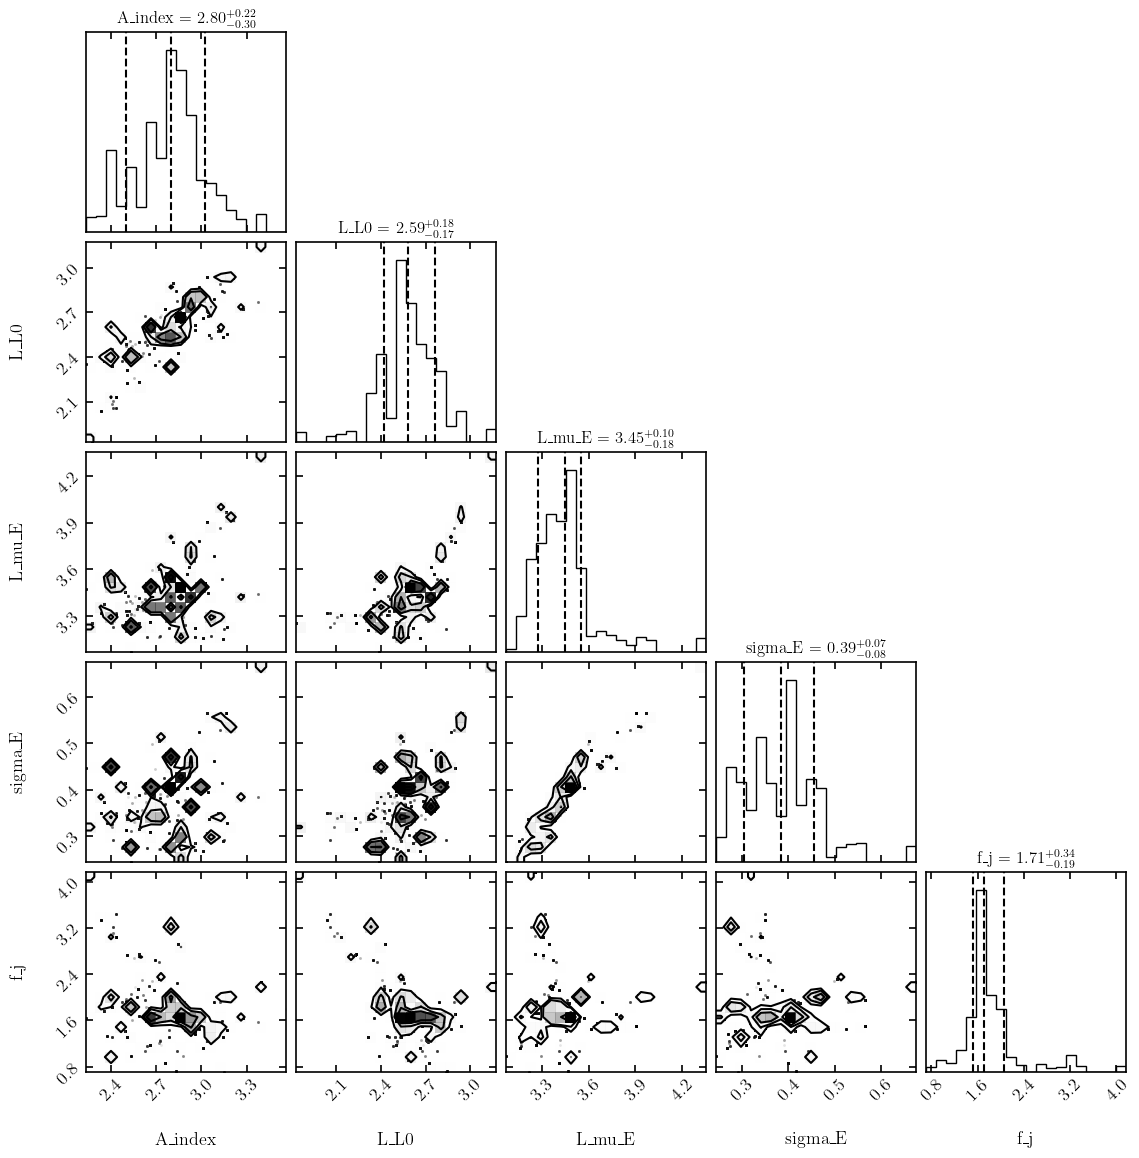

In [44]:
# corner plot
import corner
figure = corner.corner(
    flat_samples,
    labels=PARAM_NAMES,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt='.2f',
    title_kwargs={'fontsize': 12},
)
plt.show()

## Recover $E_{iso}$ from Best-Fit — 1-year catalogue with $\theta_v \leq 15^\circ$ cut

- Draw exactly $N_{GRB} = \text{round}(|z\_arr| \times f_j)$ events (1 yr).
- Assign each a random isotropic viewing angle: $\theta_v = \arccos(1-u)$, $u \sim \mathcal{U}(0,1)$.
- Keep only $\theta_v \leq 15^\circ$ (afterglow-detectable sky).
- Convert peak luminosity → $E_{iso}$ via $E_{iso} \approx \xi \, L_{peak} \, T$.

In [47]:
def recover_e_iso(peak_luminosity_L, duration_T=1.0, xi=0.3):
    """
    Recover E_iso from peak luminosity (Salafia et al. 2023).

    E_iso ~ xi * L_peak * T
    """
    return xi * peak_luminosity_L * duration_T


# ── Best-fit 1-year extraction ─────────────────────────────────────────────────
distances = compute_luminosity_distance(default_params.z_arr)

A_index_best, L_L0_best, L_mu_E_best, sigma_E_best, fj_best = best_theta

n_bns_1yr = len(default_params.z_arr)
n_grb_1yr = max(int(np.round(n_bns_1yr * fj_best)), 1)

rng = np.random.default_rng(123)

sim_best = simplified_montecarlo(
    best_theta,
    n_events   = n_grb_1yr,
    params_in  = default_params,
    distances  = distances,
    k_interpolator = k_interpolator,
    rng        = rng,
)

# Isotropic viewing angle: p(theta) ~ sin(theta)  → theta = arccos(1 - u)
u            = rng.uniform(0.0, 1.0, size=n_grb_1yr)
theta_v_rad  = np.arccos(1.0 - u)
theta_v_deg  = np.degrees(theta_v_rad)

# Afterglow catalogue cut
mask          = theta_v_deg <= 15.0
L_peak_out    = sim_best['L_p_obs'][mask]
z_out         = sim_best['z_arr'][mask]
theta_v_out   = theta_v_deg[mask]
E_iso_out     = recover_e_iso(L_peak_out, duration_T=1.0, xi=0.3)

print('Best-fit parameters:')
for name, val in zip(PARAM_NAMES, best_theta):
    print(f'  {name:>10s} = {val:.4f}')

print(f'\nBNS in 1 yr (z_arr)          : {n_bns_1yr:,}')
print(f'GRB emitters in 1 yr (×f_j)  : {n_grb_1yr:,}')
print(f'After θ_v ≤ 15° cut           : {int(mask.sum()):,}')
print(f'\nMedian log10(L_peak)          : {np.median(np.log10(L_peak_out)):.3f}')
print(f'Median log10(E_iso)           : {np.median(np.log10(E_iso_out)):.3f}')
print('E_iso 16-50-84 percentiles:')
print(np.percentile(E_iso_out, [16, 50, 84]))

Best-fit parameters:
     A_index = 2.8000
        L_L0 = 2.5662
      L_mu_E = 3.5494
     sigma_E = 0.4610
         f_j = 2.0495

BNS in 1 yr (z_arr)          : 359,079
GRB emitters in 1 yr (×f_j)  : 735,947
After θ_v ≤ 15° cut           : 25,271

Median log10(L_peak)          : 51.726
Median log10(E_iso)           : 51.203
E_iso 16-50-84 percentiles:
[1.02442363e+51 1.59712238e+51 3.21568564e+51]


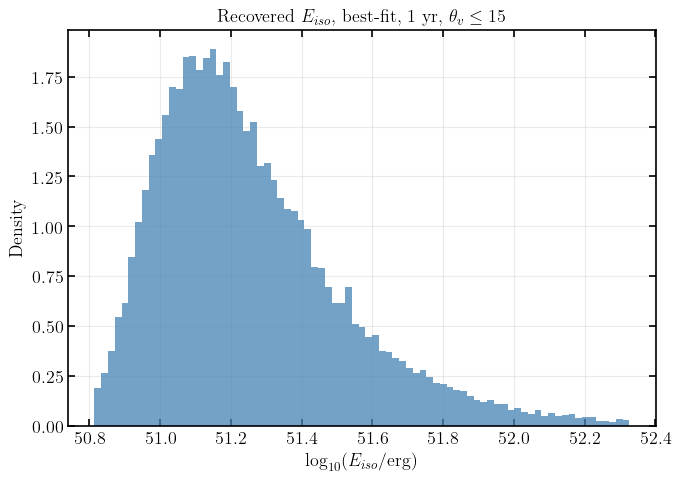

Saved to Output_files/Paper_Results/Universal_TopHat_theta5_2Dbin


In [48]:
# ── Plot and save ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
bins = np.linspace(
    np.percentile(np.log10(E_iso_out), 0.5),
    np.percentile(np.log10(E_iso_out), 99.5),
    80,
)
ax.hist(np.log10(E_iso_out), bins=bins, density=True, alpha=0.75, color='steelblue')
ax.set_xlabel(r'$\log_{10}(E_{iso}/\mathrm{erg})$')
ax.set_ylabel('Density')
ax.set_title(r'Recovered $E_{iso}$, best-fit, 1 yr, $\theta_v \leq 15°$')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(output_dir / 'Eiso_bestfit_1yr_theta15.pdf', dpi=300)
plt.show()

# ── Save CSV ───────────────────────────────────────────────────────────────────
summary = {
    'theta_c_fixed_deg'  : THETA_C_DEG_FIXED,
    'factor'             : FACTOR,
    'xi'                 : 0.3,
    'duration_T_s'       : 1.0,
    'f_j_best'           : float(fj_best),
    'n_bns_1yr'          : int(n_bns_1yr),
    'n_grb_1yr'          : int(n_grb_1yr),
    'n_afterglow_theta15': int(mask.sum()),
    'log10_Eiso_p16'     : float(np.percentile(np.log10(E_iso_out), 16)),
    'log10_Eiso_p50'     : float(np.percentile(np.log10(E_iso_out), 50)),
    'log10_Eiso_p84'     : float(np.percentile(np.log10(E_iso_out), 84)),
}
pd.DataFrame([summary]).to_csv(output_dir / 'Eiso_summary_2Dbin.csv', index=False)

pd.DataFrame({
    'z'           : z_out,
    'theta_v_deg' : theta_v_out,
    'L_peak_erg_s': L_peak_out,
    'E_iso_erg'   : E_iso_out,
}).to_csv(output_dir / 'Eiso_samples_2Dbin.csv', index=False)

print('Saved to', output_dir)